In [1]:
!pip install earthengine-api geemap rasterio scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.6 MB/s eta 0:00:00


In [2]:
import ee

ee.Authenticate()

ee.Initialize(project='gen-lang-client-0412024487') # Replace 'your-project-id' with your actual Google Cloud Project ID

In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets"

folders = [
    "saudi_eastern_province/raw/dem/elevation",

    "saudi_eastern_province/processed/terrain",

    "saudi_eastern_province/grids/32x32",

    "saudi_eastern_province/grids/64x64"
]

for folder in folders:
    os.makedirs(os.path.join(BASE, folder), exist_ok=True)

print("DEM folders created.")

DEM folders created.


In [5]:
saudi_roi = ee.Geometry.Rectangle([
    45.5,
    23.5,
    50.5,
    28.5
])

In [6]:
dem = ee.Image("USGS/SRTMGL1_003")

In [7]:
dem_saudi = dem.clip(saudi_roi)

In [8]:
terrain = ee.Terrain.products(dem_saudi)

slope = terrain.select('slope')

In [9]:
import geemap

Map = geemap.Map(center=[26.5, 48], zoom=6)

elevation_vis = {
    'min': 0,
    'max': 1000,
    'palette': ['blue', 'green', 'yellow', 'brown']
}

Map.addLayer(dem_saudi, elevation_vis, "Elevation")

Map

Map(center=[26.5, 48], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [10]:
Map = geemap.Map(center=[26.5, 48], zoom=6)

slope_vis = {
    'min': 0,
    'max': 30,
    'palette': ['white', 'yellow', 'orange', 'red']
}

Map.addLayer(slope, slope_vis, "Slope")

Map

Map(center=[26.5, 48], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

In [19]:
import geemap

output_tif = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/raw/dem/elevation/saudi_slope.tif"

geemap.ee_export_image(
    slope,
    filename=output_tif,
    scale=250,
    region=saudi_roi,
    file_per_band=False
)

print("Slope exported.")

Generating URL ...
Please wait ...
Data downloaded to /content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/raw/dem/elevation/saudi_slope.tif
Slope exported.


In [20]:
import rasterio

tif_path = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/raw/dem/elevation/saudi_slope.tif"

src = rasterio.open(tif_path)

slope_data = src.read(1)

print("Shape:", slope_data.shape)

Shape: (2237, 2227)


In [21]:
import numpy as np

print("Min:", np.min(slope_data))
print("Max:", np.max(slope_data))
print("Mean:", np.mean(slope_data))
print("NaNs:", np.isnan(slope_data).sum())

Min: 0
Max: 34
Mean: 0.5819684816669641
NaNs: 0


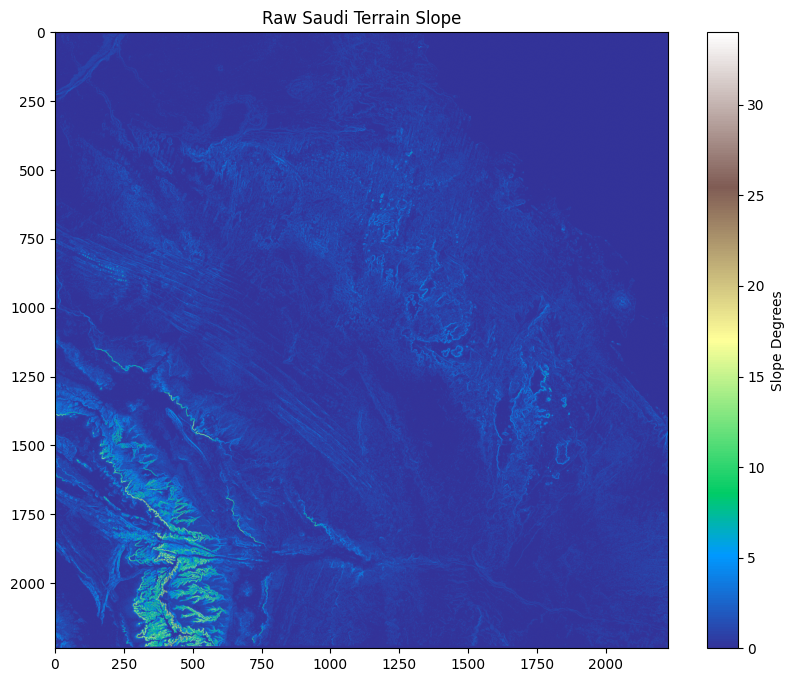

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(slope_data, cmap='terrain')

plt.title("Raw Saudi Terrain Slope")

plt.colorbar(label="Slope Degrees")

plt.show()

In [23]:
slope_data = slope_data.astype(np.float32)

slope_data = np.nan_to_num(slope_data)

In [24]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

slope_norm = normalize(slope_data)

In [25]:
print("Min:", np.min(slope_norm))
print("Max:", np.max(slope_norm))

Min: 0.0
Max: 1.0


In [26]:
!pip install scikit-image

In [32]:
from skimage.transform import resize

In [31]:
terrain_32 = resize(slope_norm, (32,32))

terrain_64 = resize(slope_norm, (64,64))

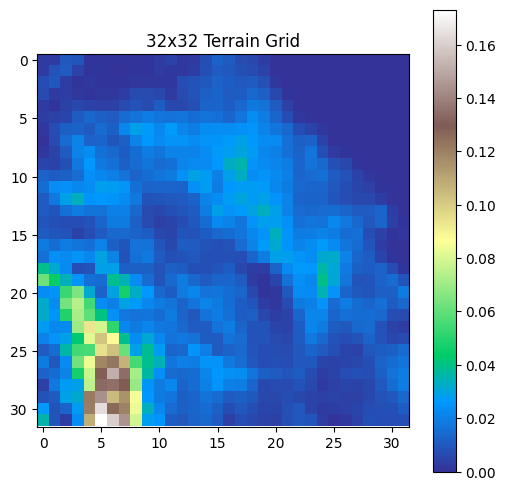

In [33]:
plt.figure(figsize=(6,6))

plt.imshow(terrain_32, cmap='terrain')

plt.title("32x32 Terrain Grid")

plt.colorbar()

plt.show()

In [34]:
GRID_BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/saudi_eastern_province/grids"

In [35]:
np.save(
    f"{GRID_BASE}/32x32/terrain.npy",
    terrain_32
)

np.save(
    f"{GRID_BASE}/64x64/terrain.npy",
    terrain_64
)

print("Terrain grids saved.")

Terrain grids saved.


In [36]:
import os

print(os.listdir(f"{GRID_BASE}/32x32"))

['wind_x.npy', 'wind_y.npy', 'temperature.npy', 'humidity.npy', 'fuel.npy', 'state_tensor.npy', 'terrain.npy']


In [37]:
terrain_test = np.load(f"{GRID_BASE}/32x32/terrain.npy")

print(terrain_test.shape)

print(terrain_test.min())

print(terrain_test.max())

(32, 32)
0.0
0.17321377


In [39]:
print("Raw slope min:", slope_data.min())

print("Raw slope max:", slope_data.max())

print("Raw slope mean:", slope_data.mean())

Raw slope min: 0.0
Raw slope max: 34.0
Raw slope mean: 0.5819685


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PyroRL_Saudi_Project/visualizations/terrain_32.png'

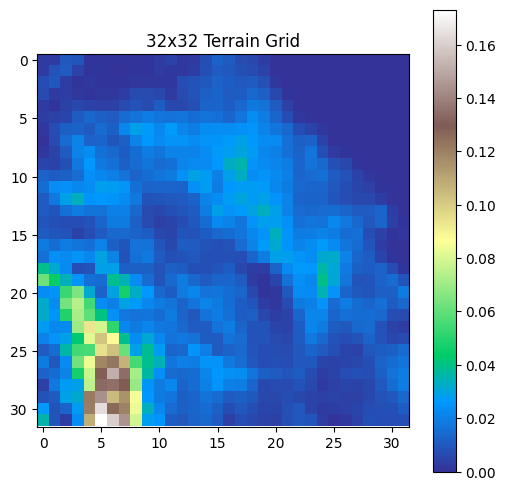

In [41]:
save_path = "/content/drive/MyDrive/PyroRL_Saudi_Project/visualizations/terrain_32.png"

plt.figure(figsize=(6,6))

plt.imshow(terrain_32, cmap='terrain')

plt.title("32x32 Terrain Grid")

plt.colorbar()

plt.savefig(save_path, dpi=300)

plt.show()

print("Visualization saved.")

In [42]:
import json

metadata = {
    "dataset": "SRTM DEM",
    "region": "Saudi Eastern Province",
    "source_resolution_m": 250,
    "grid_sizes": [32, 64],
    "terrain_representation": "slope",
    "normalization": "minmax"
}

metadata_path = f"{GRID_BASE}/terrain_metadata.json"

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved.")

Metadata saved.
